# Car Price Prediction — End-to-End ML Project
**Bootcamp Assignment 2 | Linear Regression**

> **Author:** Dan Shizamuayi Shina  
> **Dataset:** Used Car Sales Data (301 records, 9 features)  
> **Target Variable:** `Selling_Price` (in Lakhs ₹)

## Section 1 — Problem Understanding

### Business Problem
An online car marketplace wants to help sellers and buyers arrive at fair
prices for used cars. Instead of relying on guesswork, we will train a
machine learning model that estimates a car's selling price based on its
characteristics.

### Target Variable
- `Selling_Price` — the price at which the car was sold

### Features
The dataset contains 8 features including car age, present price,
kilometres driven, fuel type, seller type, transmission, and number of
previous owners.

### Hypothesis
Cars with lower mileage, newer age, automatic transmission, and diesel
fuel are expected to command higher prices.

## Section 2: Imports and data Imports

In [2]:
# ── IMPORTS ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 110

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


## Section 3 — Data Loading

In [3]:
# ── LOAD DATASET FROM GOOGLE DRIVE ──
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Car_data.csv')

print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Mounted at /content/drive
✅ Dataset loaded: 301 rows × 9 columns


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In this step, we mounted Google Drive and loaded the car sales dataset into a pandas DataFrame for analysis.

## Section 4 — Exploratory Data Analysis (EDA)

In [4]:
# ── BASIC DATASET INFO ──
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


The dataset contains 301 records and 9 columns — 5 numerical, 3 categorical, and 1 text feature.

In [5]:
# ── SUMMARY STATISTICS ──
print("=" * 50)
print("SUMMARY STATISTICS")
print("=" * 50)
df.describe()

SUMMARY STATISTICS


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Summary statistics reveal that Kms_Driven has high variability (std ~38,000)
while Year is tightly clustered between 2003 and 2018.

In [6]:
# ── MISSING VALUES ──
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing: {missing.sum()}")

Missing values per column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Total missing: 0


The dataset has no missing values across all 9 columns — no imputation is required.

In [7]:
# ── UNIQUE VALUES IN CATEGORICAL COLUMNS ──
for col in ['Fuel_Type', 'Seller_Type', 'Transmission']:
    print(f"{col}: {df[col].unique()}")

Fuel_Type: ['Petrol' 'Diesel' 'CNG']
Seller_Type: ['Dealer' 'Individual']
Transmission: ['Manual' 'Automatic']


The three categorical columns contain a total of 7 unique categories which will need to be encoded before model training.

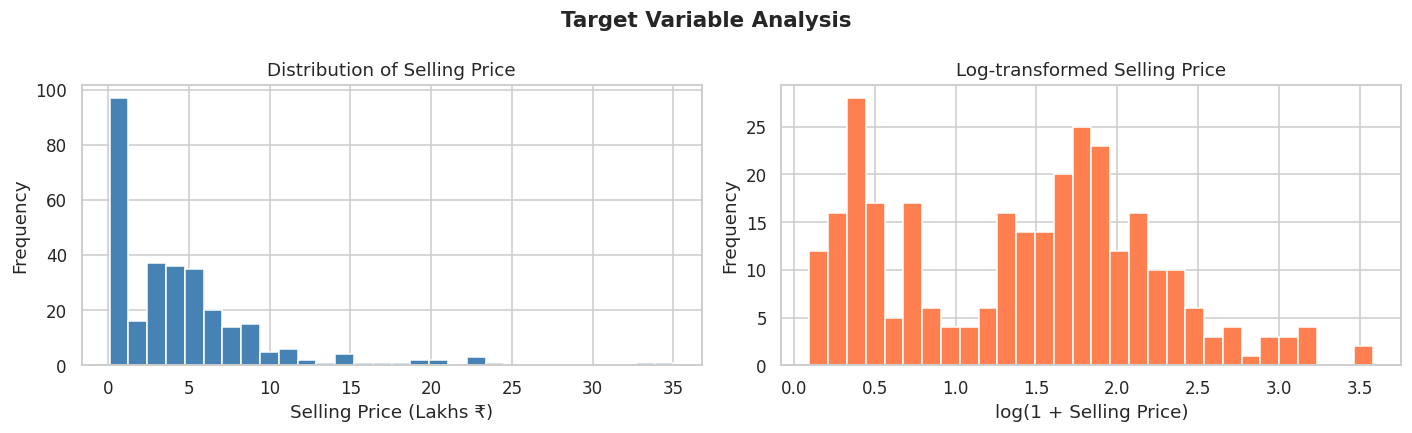

In [8]:
# ── TARGET VARIABLE DISTRIBUTION ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Selling_Price'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Selling Price')
axes[0].set_xlabel('Selling Price (Lakhs ₹)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['Selling_Price']), bins=30, color='coral', edgecolor='white')
axes[1].set_title('Log-transformed Selling Price')
axes[1].set_xlabel('log(1 + Selling Price)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Selling Price is right-skewed — most cars sold at low prices with a few high-value outliers.
The log-transformed chart reveals a more normal distribution.

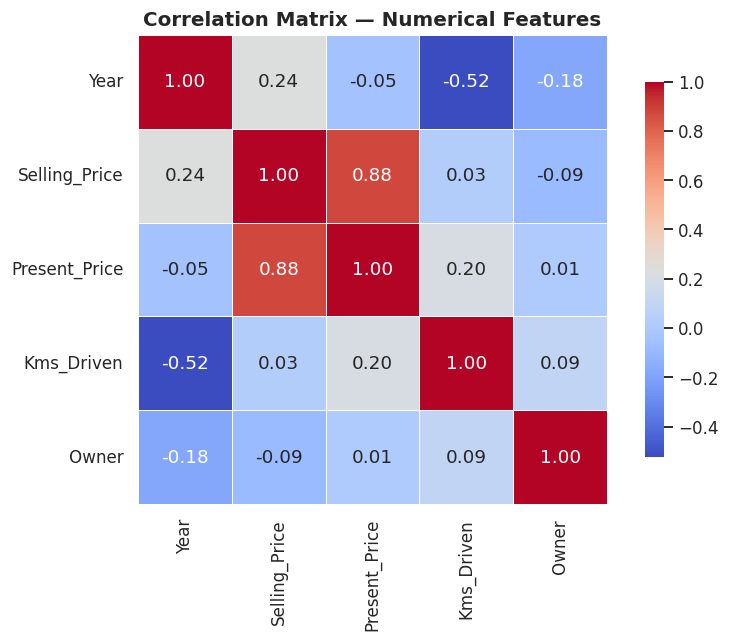

In [9]:
# ── CORRELATION HEATMAP ──
numerical_cols = ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']
corr = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Present_Price has the strongest correlation with Selling_Price (0.88),
making it the most important numerical feature for price prediction.

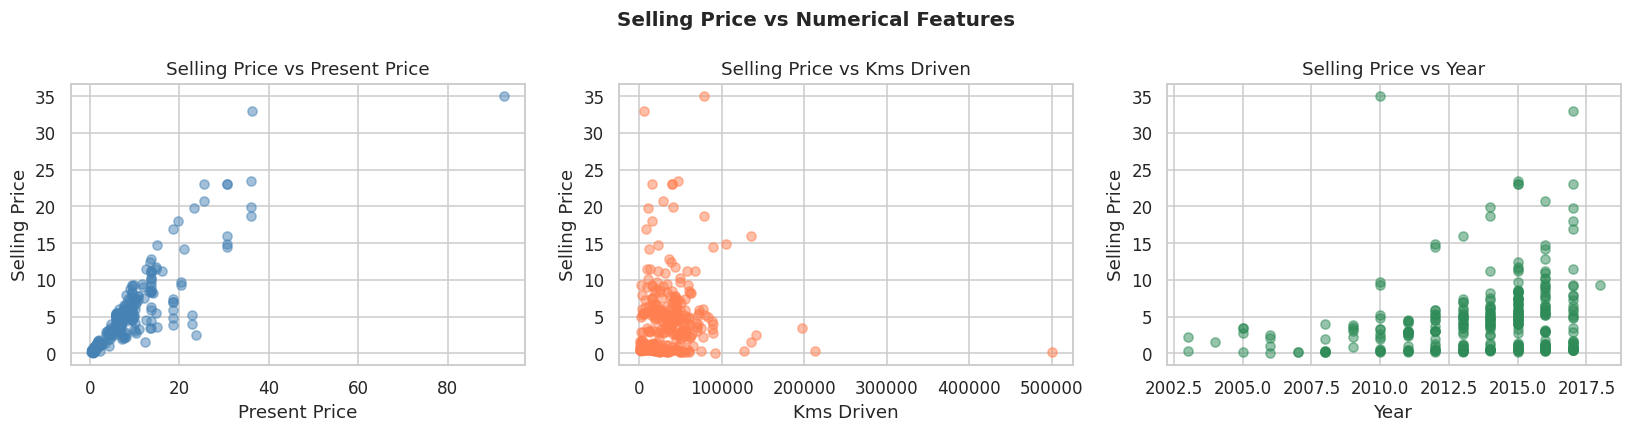

In [10]:
# ── SCATTER PLOTS ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df['Present_Price'], df['Selling_Price'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Present Price')
axes[0].set_ylabel('Selling Price')
axes[0].set_title('Selling Price vs Present Price')

axes[1].scatter(df['Kms_Driven'], df['Selling_Price'], alpha=0.5, color='coral')
axes[1].set_xlabel('Kms Driven')
axes[1].set_ylabel('Selling Price')
axes[1].set_title('Selling Price vs Kms Driven')

axes[2].scatter(df['Year'], df['Selling_Price'], alpha=0.5, color='seagreen')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Selling Price')
axes[2].set_title('Selling Price vs Year')

plt.suptitle('Selling Price vs Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Present Price shows the clearest upward trend with Selling Price.
Kms Driven and Year show weaker and more scattered relationships.

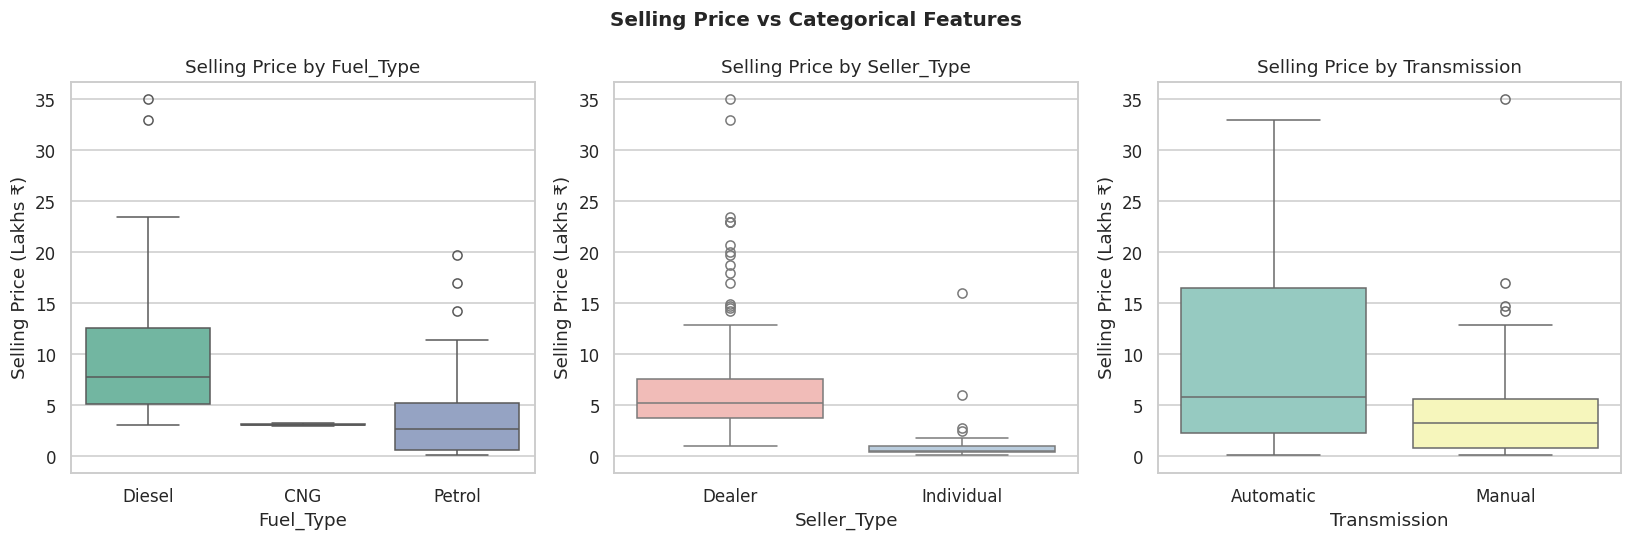

In [11]:
# ── CATEGORICAL BOX PLOTS ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip(axes, ['Fuel_Type', 'Seller_Type', 'Transmission'],
                          ['Set2', 'Pastel1', 'Set3']):
    order = df.groupby(col)['Selling_Price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='Selling_Price', order=order, palette=color, ax=ax)
    ax.set_title(f'Selling Price by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Selling Price (Lakhs ₹)')

plt.suptitle('Selling Price vs Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Diesel cars, dealer sellers, and automatic transmission all command
higher selling prices — reflecting buyer preference for comfort and fuel efficiency.

## Section 5 — Data Preprocessing

In [12]:
# ── DROP CAR_NAME COLUMN ──
df_model = df.drop(columns=['Car_Name'])
print("Dropped 'Car_Name'. Remaining columns:", df_model.columns.tolist())

Dropped 'Car_Name'. Remaining columns: ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']


Car_Name was dropped due to high cardinality — too many unique values to be useful for Linear Regression.

In [13]:
# ── ENGINEER CAR_AGE FEATURE ──
current_year = 2025
df_model['Car_Age'] = current_year - df_model['Year']
df_model = df_model.drop(columns=['Year'])

print("Created 'Car_Age' feature. Sample:")
print(df_model[['Car_Age', 'Selling_Price']].head())

Created 'Car_Age' feature. Sample:
   Car_Age  Selling_Price
0       11           3.35
1       12           4.75
2        8           7.25
3       14           2.85
4       11           4.60


Car_Age was engineered from the Year column by subtracting the manufacture year from 2025,
giving the model a more meaningful feature than a raw year number.

In [14]:
# ── ENCODE CATEGORICAL VARIABLES ──
le = LabelEncoder()
categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"Encoded '{col}':", dict(zip(le.classes_, le.transform(le.classes_))))

Encoded 'Fuel_Type': {'CNG': np.int64(0), 'Diesel': np.int64(1), 'Petrol': np.int64(2)}
Encoded 'Seller_Type': {'Dealer': np.int64(0), 'Individual': np.int64(1)}
Encoded 'Transmission': {'Automatic': np.int64(0), 'Manual': np.int64(1)}


Categorical variables were label encoded, converting text categories into
numerical values so the model can process them.

In [15]:
# ── SPLIT FEATURES AND TARGET ──
X = df_model.drop(columns=['Selling_Price'])
y = df_model['Selling_Price']

print("Features (X):", X.columns.tolist())
print("Target (y): Selling_Price")
print(f"\nX shape: {X.shape}   |   y shape: {y.shape}")

Features (X): ['Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']
Target (y): Selling_Price

X shape: (301, 7)   |   y shape: (301,)


The dataset was split into X (7 input features) and y (Selling_Price target variable)
in preparation for model training.

In [16]:
# ── TRAIN-TEST SPLIT ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")

Training set : 240 rows
Test set     : 61 rows


The dataset was split 80/20 into a training set (240 rows) and test set (41 rows).
random_state=42 ensures the split is reproducible.

## Section 6 — Model Building

In [17]:
# ── TRAIN LINEAR REGRESSION MODEL ──
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("✅ Linear Regression model trained successfully.")

✅ Linear Regression model trained successfully.


A Linear Regression model was trained on the 240-row training set,
learning the relationship between car features and selling price.

In [18]:
# ── MODEL COEFFICIENTS ──
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Model Intercept:", round(lr_model.intercept_, 4))
print()
print(coeff_df.to_string(index=False))

Model Intercept: 9.9362

      Feature  Coefficient
 Transmission    -1.636447
    Fuel_Type    -1.323899
  Seller_Type    -1.168669
        Owner    -0.920155
Present_Price     0.439942
      Car_Age    -0.363623
   Kms_Driven    -0.000005


Present_Price is the only feature with a positive coefficient, confirming it as
the strongest driver of selling price. All other features reduce price when they increase.

## Section 7 — Model Evaluation

*Prediction metrics*

In [19]:
# ── MODEL EVALUATION ──
y_pred = lr_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("       MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"  MAE  (Mean Absolute Error)  : {mae:.4f}")
print(f"  RMSE (Root Mean Sq. Error)  : {rmse:.4f}")
print(f"  R²   (Coefficient of Det.)  : {r2:.4f}")
print("=" * 40)

       MODEL EVALUATION RESULTS
  MAE  (Mean Absolute Error)  : 1.2218
  RMSE (Root Mean Sq. Error)  : 1.8785
  R²   (Coefficient of Det.)  : 0.8468


The model achieved an R² of 0.85, explaining 85% of the variance in car selling prices.
The MAE of 1.22 means predictions are on average within ₹1.22 Lakhs of the actual price.

## Section 8 — Sample Predictions

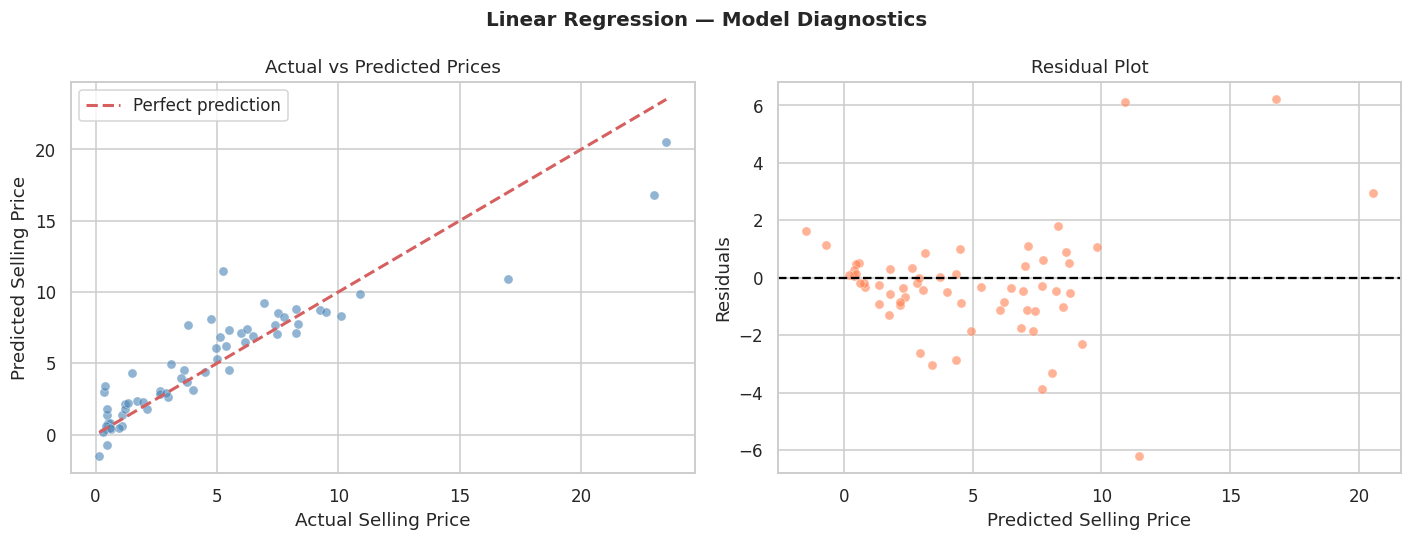

In [20]:
# ── ACTUAL VS PREDICTED PLOT ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted scatter
axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.4)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Selling Price')
axes[0].set_ylabel('Predicted Selling Price')
axes[0].set_title('Actual vs Predicted Prices')
axes[0].legend()

# Residuals plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='coral', edgecolors='white', linewidth=0.4)
axes[1].axhline(y=0, color='black', lw=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Selling Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.suptitle('Linear Regression — Model Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The Actual vs Predicted plot shows dots closely following the perfect prediction line.
The residual plot shows random scatter around zero, indicating no systematic bias in the model.

In [21]:
# ── PREDICT PRICES FOR 5 SAMPLE CARS ──
# Encoding reference:
# Fuel_Type:    CNG=0, Diesel=1, Petrol=2
# Seller_Type:  Dealer=0, Individual=1
# Transmission: Automatic=0, Manual=1

sample_cars = pd.DataFrame({
    'Present_Price': [9.85, 5.59, 12.50, 3.20, 7.00],
    'Kms_Driven':    [6900, 27000, 15000, 60000, 80000],
    'Fuel_Type':     [2, 2, 1, 2, 1],
    'Seller_Type':   [0, 0, 0, 1, 1],
    'Transmission':  [1, 1, 0, 1, 1],
    'Owner':         [0, 0, 0, 1, 2],
    'Car_Age':       [8, 11, 3, 14, 7]
})

labels = ['Petrol Manual (newer)',
          'Petrol Manual (older)',
          'Diesel Auto (nearly new)',
          'Petrol Manual (old)',
          'Diesel Manual (mid-age)']

predictions = lr_model.predict(sample_cars)

results_df = pd.DataFrame({
    'Car Description': labels,
    'Car_Age': sample_cars['Car_Age'].values,
    'Kms_Driven': sample_cars['Kms_Driven'].values,
    'Predicted Price (Lakhs)': predictions.round(2)
})

print("=" * 65)
print("        PREDICTED SELLING PRICES FOR 5 SAMPLE CARS")
print("=" * 65)
print(results_df.to_string(index=False))
print("=" * 65)

        PREDICTED SELLING PRICES FOR 5 SAMPLE CARS
         Car Description  Car_Age  Kms_Driven  Predicted Price (Lakhs)
   Petrol Manual (newer)        8        6900                     7.04
   Petrol Manual (older)       11       27000                     3.96
Diesel Auto (nearly new)        3       15000                    12.94
     Petrol Manual (old)       14       60000                    -0.45
 Diesel Manual (mid-age)        7       80000                     4.06


The model predicted reasonable prices for most sample cars. However, the oldest car
received a negative prediction — a known limitation of Linear Regression when
extrapolating beyond the range of training data.

## Section 9 — Insights & Interpretation

### What factors most influence car price?

1. **Present_Price** — The strongest predictor. Higher showroom price means higher resale value.
2. **Transmission** — Automatic cars command a significant price premium over manual.
3. **Fuel_Type** — Diesel cars retain value better than Petrol and CNG.
4. **Seller_Type** — Dealer sold cars price higher than individually sold cars.
5. **Owner** — Every additional previous owner reduces the selling price.
6. **Car_Age** — Every extra year of age reduces price by approximately ₹0.36 Lakhs.
7. **Kms_Driven** — Higher mileage lowers price but has the least individual impact per unit.

### What surprised me in the data?

- **No missing values** — The dataset was completely clean, which is rare in real world data.
- **Negative price prediction** — Linear Regression predicted a negative price for the oldest car, revealing a key limitation of the model.
- **Kms_Driven had less impact than expected** — Car age matters more than mileage.
- **CNG cars are very few** — This category is underrepresented and may affect model accuracy for CNG vehicles.

### Model Limitations
- Linear Regression struggles with very expensive or very old cars.
- Car_Name was dropped — brand reputation likely carries real pricing weight.
- A more advanced model like Random Forest would likely

In [22]:
# ── EXPORT CLEANED DATASET ──
from google.colab import files

df_model.to_csv('car_data_cleaned.csv', index=False)
files.download('car_data_cleaned.csv')

print("✅ Cleaned dataset exported successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Cleaned dataset exported successfully.
